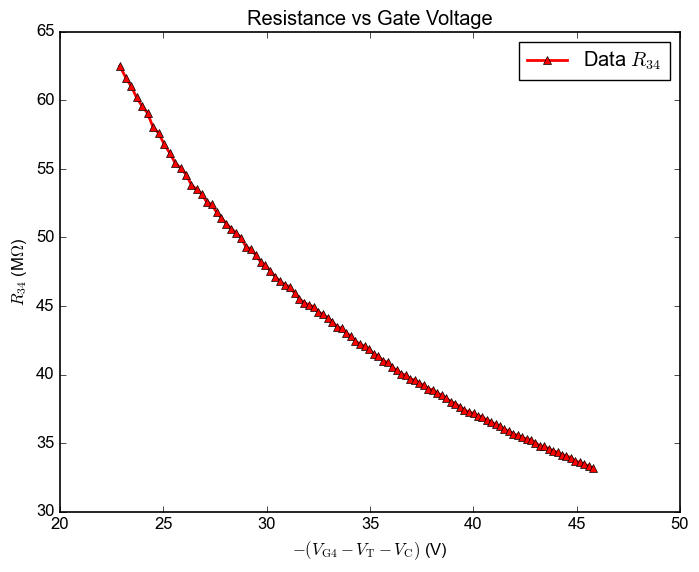

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 22,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

# IDS - VGS data
data = np.loadtxt("./Data-vdP/20262504003.dat")
V_GS = data[:, 0]  # VGS values
I_DS = data[:, 2]  # IDS values
V_DS = data[:, 3]  # VDS values
sigma = data[:, 7]

V_C = 0.5*(data[:, 4] + data[:, 5])
R_DS = V_DS / I_DS  # Calculate resistance
V_T = -5.9
C =	2.6e-9	# F
A = 45e-6	# m^2
Ci = C/A # F/m^2
mu = 3.55e-4	# m^2/Vs

x = V_GS - V_T - V_C

plt.plot(-x, R_DS*1e-6, lw=2, label=r'Data $R_\text{34}$', color='red', marker='^', linestyle='-', markevery=1)
plt.xlabel(r"$-(V_\text{G4}- V_\text{T} - V_\text{C})$ (V)")
plt.ylabel(r"$R_\text{34}$ (M$\Omega$)")
# plt.xlim(5,30)
# plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()


a = 4.26704e+06 ± 1.12e+05
b = -1.31516e+09 ± 3.66e+06
R^2 = 0.999233
--------------------------------------
Rc = (4.26704 ± 0.112) MΩ


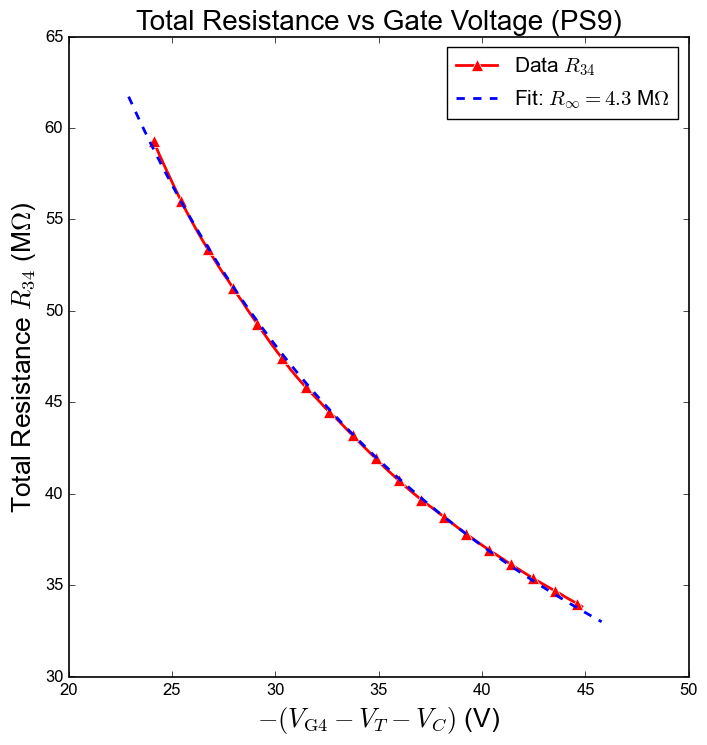

In [ ]:
def func(x, a, b):
    return a + b / x

# Use only finite points in the requested fit window: 5 <= -x <= 30
mask = np.isfinite(x) & np.isfinite(R_DS) & (-x >= 20) & (-x <= 50)
x_fit = x[mask]
R_fit_data = R_DS[mask]

# Target b value corresponding to mu = 3 cm^2/Vs
b_target = -np.log(2) / (np.pi * Ci * 1e-4 * 3)
a0 = np.median(R_fit_data)

# Fit Rc + b/x to the selected x-range
popt, pcov = curve_fit(
    func,
    x_fit,
    R_fit_data,
    p0=(a0, b_target),
    bounds=([-np.inf, -np.inf], [np.inf, 0]),
)
R_fit = func(x_fit, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_fit_data - R_fit) ** 2)
ss_tot = np.sum((R_fit_data - np.mean(R_fit_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr



R_fit = func(x_fit, a, b)


print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")
print("--------------------------------------")
print(f"Rc = ({a*1e-6:.6g} ± {a_err*1e-6:.3g}) MΩ")

# x_test = np.linspace(-50, -15, 100)
# R_test = func(x_test, a, b)

window_size = 10
window = np.ones(window_size) / window_size
x_smooth = np.convolve(x, window, mode='valid')
R_DS_smooth = np.convolve(R_DS, window, mode='valid')

plt.figure(figsize=(8, 8))
plt.plot(-x_smooth, R_DS_smooth*1e-6, label=r'Data $R_\text{34}$', color='red', marker='^', ls='-', lw=2, markevery=5,markeredgecolor="white", markeredgewidth=0.5, markersize=8)
plt.plot(-x_fit, R_fit*1e-6, lw=2, label=rf'Fit: $R_\infty = {a*1e-6:.2g}$ M$\Omega$', color='blue', linestyle='--')
# plt.plot(-x_test, R_test*1e-6, lw=2, label=rf'Test: $R_C = {a*1e-6:.2g}$ M$\Omega$', color='green', linestyle='-.')
plt.xlabel(r"$-(V_\text{G4}- V_T - V_C)$ (V)", fontsize=19)
plt.ylabel(r"Total Resistance $R_\text{34}$ (M$\Omega$)", fontsize=19)
# plt.xlim(5,30)
# plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=15)
plt.title("Total Resistance vs Gate Voltage (PS9)", fontsize=20)
# plt.savefig("total_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

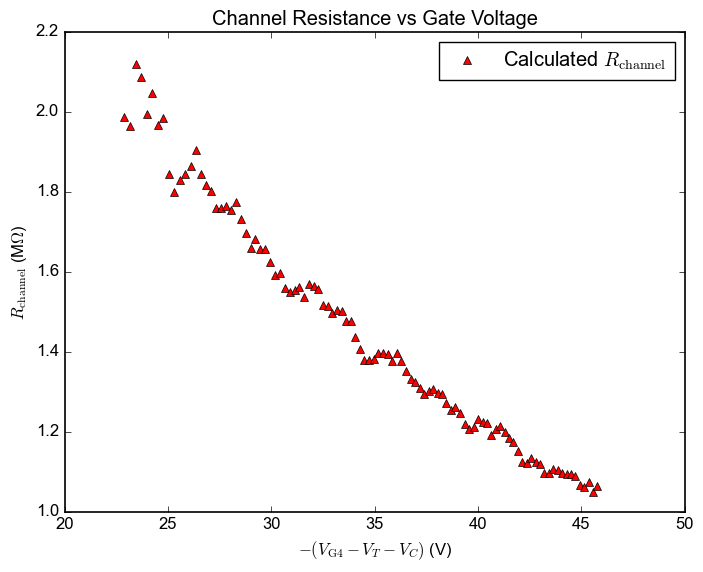

In [23]:
R_channel = 1/sigma

plt.plot(-x, R_channel*1e-6, lw=2, label=r'Calculated $R_\text{channel}$', color='red', marker='^', linestyle='None', markevery=1)
plt.xlabel(r"$-(V_\text{G4}- V_T - V_C)$ (V)")
plt.ylabel(r"$R_\text{channel}$ (M$\Omega$)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Channel Resistance vs Gate Voltage")
plt.show()


a = 36160.1 ± 1.7e+04
b = -4.74625e+07 ± 5.59e+05
R^2 = 0.986470
--------------------------------------
Rc = (0.0361601 ± 0.017) MΩ


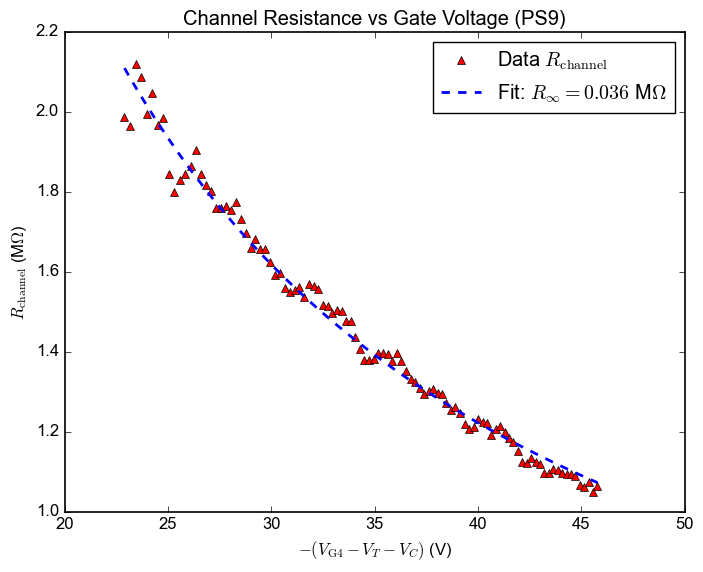

In [24]:
def func(x, a, b):
    return a + b / x

# Use only finite points in the requested fit window: 5 <= -x <= 30
mask = np.isfinite(x) & np.isfinite(R_DS) & (-x >= 20) & (-x <= 50)
x_fit = x[mask]
R_fit_data = R_channel[mask]

# Target b value corresponding to mu = 3 cm^2/Vs
b_target = -np.log(2) / (np.pi * Ci * 1e-4 * 3)
a0 = np.median(R_fit_data)

# Fit Rc + b/x to the selected x-range
popt, pcov = curve_fit(
    func,
    x_fit,
    R_fit_data,
    p0=(a0, b_target),
    bounds=([-np.inf, -np.inf], [np.inf, 0]),
)
R_fit = func(x_fit, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_fit_data - R_fit) ** 2)
ss_tot = np.sum((R_fit_data - np.mean(R_fit_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr



R_fit = func(x_fit, a, b)


print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")
print("--------------------------------------")
print(f"Rc = ({a*1e-6:.6g} ± {a_err*1e-6:.3g}) MΩ")

# x_test = np.linspace(-50, -15, 100)
# R_test = func(x_test, a, b)

plt.plot(-x, R_channel*1e-6, lw=2, label=r'Data $R_\text{channel}$', color='red', marker='^', linestyle='None', markevery=1)
plt.plot(-x_fit, R_fit*1e-6, lw=2, label=rf'Fit: $R_\infty = {a*1e-6:.2g}$ M$\Omega$', color='blue', linestyle='--')
# plt.plot(-x_test, R_test*1e-6, lw=2, label=rf'Test: $R_C = {a*1e-6:.2g}$ M$\Omega$', color='green', linestyle='-.')
plt.xlabel(r"$-(V_\text{G4}- V_T - V_C)$ (V)")
plt.ylabel(r"$R_\text{channel}$ (M$\Omega$)")
# plt.xlim(5,30)
# plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Channel Resistance vs Gate Voltage (PS9)")
# plt.savefig("channel_PS9.eps", format='eps', bbox_inches='tight')
plt.show()